# Introduction

In this project, we work on the spatio-temporal prediction of infectious diseases. While measles is considered the prime target, it is a difficult disease to model. Besides the nature of its epidemiology, rather sporadic and outbreak-associated, it is a relatively rare disease. As case numbers are low, machine learning algorithms struggle to find patterns in the past epidemiology when looking at Kreis-level epidemiology in Germany.

As such, influenza is used as a benchmarking-disease if you will. Providing a rich signal over space as well as time, influenza predictions may show what model architectures are useful for this task.

### Prediction Framework

I find it very important to work adaptively. What I mean by this is that whatever I create, I want to be able to explore different sets of parameters and see what happens. As such, I have created a pipeline in which I instantiate an *epidataloader*, a class that contains a dataframe with input features and target variables, based on an input configuration describing the task at hand.

**Notation**

Let $j \in \mathcal{J}$ denote a Kreis (NUTS-3 region), where $\mathcal{J}$ represents the set of all Kreise in Germany. Let $t$ denote the time index (in weeks). We define the following temporal parameters:

- $h$: the forecast horizon (number of weeks ahead to predict)
- $w$: the input window size (number of historical weeks used as input)

Let $x_j^{(t)}$ represent the input features for Kreis $j$ at time $t$ (including lagged target values and an optinoal range of other variables), $y_j^{(t)}$ the observed influenza incidence, and $\hat{y}_j^{(t)}$ the predicted incidence. The prediction task is formulated as:

$$\hat{y}_{i}^{(t+h)} = f(\{x_j^{(t-w+1:t)}, y_j^{(t-w+1:t)}\}_{j \in \mathcal{J}})$$

where the model leverages spatio-temporal information from all Kreise to predict the target Kreis $i$ at horizon $h$.

In [ ]:
# !hpc-ticket
# !hpc-mount wissdaten

### Standard epidataloader

Below we create the default epidataloader: the data that highlights the task at hand. By default for influenza, we work on the following:

- spatial resolution: nuts3 (Kreisen, n = 400 (Berlin united))
- date-range: 2011/06/01 - 2020/06/01 
- horizon size: 1
- horizon leadtime: 3
- number of lags: 1
- target: incidence

concretely, we aim to predict the incidence of influenza 3 weeks ahead per Kreis.

So let's investigate what our dataloader looks like for an example: Hannover

### Baseline performance

It is pertinent to compare model performance to baseline performance. As such, we developed three baselines:

**Persistence Model**

The persistence model assumes temporal persistence, returning the most recent observation. Formally the persistence model predicts:

$$\hat{y}_{i}^{(t+h)} = y_i^{(t)}$$

**Climateology Model**

The climatology model exploits seasonal patterns by predicting based on historical averages for position in the seasonal cycle. For a target Kreis $i$ at time $t+h$ with timepoint number (relative to its seasonality) $t_N$, the model predicts:

$$\hat{y}_{i}^{(t+h)} = \frac{1}{|\mathcal{T}_{\text{train}}(t_N)|} \sum_{t' \in \mathcal{T}_{\text{train}}(t_N)} y_i^{(t')}$$

where $\mathcal{T}_{\text{train}}(w)$ denotes all time points in the training set corresponding to position in the seasonal cycle $t_N$.

**Climascale Model**

The climascale model is a hybrid of the persistence and the climateology model. It takes a seasonal baseline, analogous to the climateology model, and scales it relative to the most recent observations.

$$\hat{y}_i^{(t+h)} = \bar{y}^{(t_N)}\cdot\frac{y_i^{(t)}}{\bar{y}_i^{(t_N^{current})}}$$

where $\bar{y}_i^{(t_N)}$ is equal to the prediction by the climateology model. Further, $\bar{y}_i^{(t_N^{current})}$ is the seasonal mean at the most recent observation.

In [2]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

epiconfig= EpiConfig.load_config('default_influenza_point_prediction')
data_orch= EpiDataOrchestrator(epiconfig).build()

EpiConfig default_influenza_point_prediction loaded


In [3]:
print(epiconfig)

<EpiConfig(
    ============   MAIN   ============
    disease                    : influenza

    ============   TEMPORAL   ============
    temporal_frequency         : w
    min_date                   : 2011-06-01
    max_date                   : 2020-06-01
    split_trainval             : 2018-06-01
    split_valtest              : 2019-06-01

    ============   GEOGRAPHY   ============
    nuts_level                 : nuts3
    split_berlin               : False

    ============   TASK CONFIG   ============
    horizon_size               : 1
    horizon_leadtime           : 3
    quantiles                  : None
    prediction_mode            : regression
    predict_difference         : False

    ============   FEATURES   ============
    time_index_d               : False
    time_index_w               : True
    time_index_m               : False
    lag_column                 : incidence
    lag_num                    : 1
    sequence_length            : 4
    incidence_sca

In [4]:
baseline_data           = BaseLineDataLoaderManager(data_orch)
constant_predictor      = ConstantModel(baseline_data)
persistence_predictor   = PersistenceModel(baseline_data)
climateology            = ClimateologyModel(baseline_data)
climascale              = ClimaScaleModel(baseline_data)

node_sample = 26

constant_predictor.set_model_hparams(0)
constant_predictor.train()
constant_predictor.forecast('test')

persistence_predictor.train()
persistence_predictor.forecast('test')

climateology.train()
climateology.forecast('test')

climascale.train()
climascale.forecast('test')

ClimaScaleModel(name='climascale_model')

In [5]:
raw_f1 = constant_predictor.show_forecasts([node_sample], 'test')
raw_f2 = persistence_predictor.show_forecasts([node_sample], 'test')
raw_f3 = climateology.show_forecasts([node_sample], 'test')
raw_f4 = climascale.show_forecasts([node_sample], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Zero model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','zero model'])
      .change_figsize(10,4).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,4).legend.move('upper left'))

f3 = (raw_f3
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,4).legend.move('upper left'))

f4 = (raw_f4
      .labels.change_suptitle('ClimaScale model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climascale model'])
      .change_figsize(10,4).legend.move('upper left'))

### Evaluation

A regular (R)MSE or (S)MAPE value won't do for the proper evaluation of metrics. These values do not "punish" persistence-like predictions properly. Persistence-like predictions are such behaviour in which the most-recently observed value is returned as prediction. They therefore produce a timeseries that "lags" with respect to the target. Instead of predicting an increase, or a decrease, the model waits until that behaviour shows up in the feature (most recently observed input) and only then predicts those patterns. It therefore misses increases when there's an actual increase, or decreases when there's actual decreases.

For that reason, I want to make use of better metrics in evaluating models. Pearson's correlation coefficient ($\rho$) might come to mind quickly. $\rho$ depicts the extent to which two variables are linearly related. In other words, when $x_1$ consistently rises, does $x_2$ do that too? For comparing the predictions to the target that makes sense, but there's a catch: $\rho$ doesn't capture any error rate between the two variables. It only measures the strength and direction of their linear relationship.

Pearson's correlation coefficient is defined as:
\begin{equation}
\rho = \frac{\sigma_{xy}}{\sigma_x \sigma_y} = \frac{\text{Cov}(x, y)}{\sigma_x \sigma_y}
\end{equation}
where $\sigma_{xy}$ is the covariance between $x$ and $y$, and $\sigma_x$ and $\sigma_y$ are the standard deviations of $x$ and $y$ respectively.

Where the covariance is a factor of how two variables change together. Specifcally, at the deviations of each varaible from its own mean.
\begin{equation}
\text{Cov}(x, y) = \sigma_{xy} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y)
\end{equation}

#### Concordance Correlation Coefficient


The concordance correlation coefficient, or **CCC**, does capture both correlation and accuracy, however. It represents a combination of a correlation value and a classic error metric, through the following formula:
\begin{equation}
\text{CCC} = \frac{2 \sigma_{xy}}{\sigma_x^2 + \sigma_y^2 + (\mu_x - \mu_y)^2}
\end{equation}
where $\sigma_{xy}$ is the covariance, $\sigma_x^2$ and $\sigma_y^2$ are the variances of $x$ and $y$, and $\mu_x$ and $\mu_y$ are the means.

The relationship between CCC and Pearson's correlation coefficient can be expressed as:
\begin{equation}
\text{CCC} = \rho \cdot C_b
\end{equation}
where $C_b$ is a bias correction factor that accounts for the deviation from the 45-degree line of perfect concordance:
\begin{equation}
C_b = \frac{2}{\frac{\sigma_x^2 + \sigma_y^2}{2\sigma_x\sigma_y} + \frac{(\mu_x - \mu_y)^2}{\sigma_x\sigma_y}}
\end{equation}

This shows that CCC equals Pearson's $\rho$ only when there is perfect agreement (no bias), meaning $\mu_x = \mu_y$ and $\sigma_x = \sigma_y$. Otherwise, CCC will be lower than $\rho$, penalizing predictions that are correlated but systematically biased or have different scales.

Below I show three example curves with correspoinding $\rho$ and $ccc$

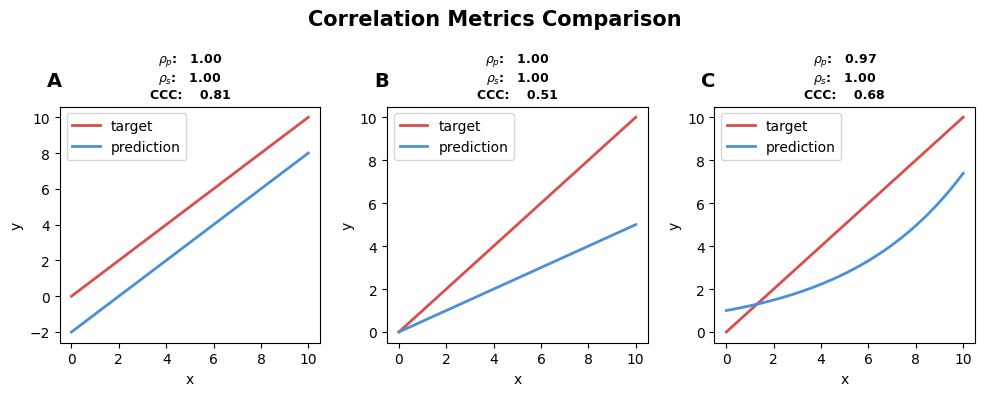

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.utils import testcolor, traincolor, valcolor

def concordance_correlation_coefficient(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov_xy = np.cov(x, y)[0, 1]
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc


x = np.linspace(0, 10, 100)

df              = pd.DataFrame(x, columns=["x"])
df['target']    = df['x']
df['pred1']     = df['x'] - 2
df['pred2']     = 0.5 * df['x']
df['pred3']     = np.exp(df['x'] / 5)

pred_columns    = ['pred1', 'pred2', 'pred3']
labels          = ['A', 'B', 'C']

fig, axes   = plt.subplots(1, 3, figsize=(10, 4))
axes        = axes.flatten()

for i, pred_col in enumerate(pred_columns):
    # Pearson Correlation
    pearson_corr = df['target'].corr(df[pred_col])
    
    # Spearman Correlation
    spearman_corr, _ = spearmanr(df['target'], df[pred_col])
    
    # Concordance Correlation Coefficient (CCC)
    ccc_value = concordance_correlation_coefficient(df['target'], df[pred_col])
    
    # Set the title for the subplot with aligned metrics
    title_text = f'$\\rho_p$: {pearson_corr:>6.2f}\n$\\rho_s$: {spearman_corr:>6.2f}\nCCC:  {ccc_value:>6.2f}'

    axes[i].set_title(title_text, fontsize=9, fontweight='bold')
    axes[i].text(-0.05, 1.15, labels[i], transform=axes[i].transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
    
    # Plot the lines for target and prediction
    sns.lineplot(df, x='x', y='target', label='target',     color=testcolor,  ax=axes[i], linewidth=2)
    sns.lineplot(df, x='x', y=pred_col, label='prediction', color=traincolor, ax=axes[i], linewidth=2)

    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

# Adjust layout
fig.suptitle('Correlation Metrics Comparison',  fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Overview of the evaluation metrics

So we now have a combination of evaluation metrics:

**Regular metrics**, namely (R)MSE and (S)MAPE

**Correlation metrics**, pearson and spearman

**cross concordance correlation**

The distribution of 4 different evaluation metrics (Figure A-D) across the 400 nodes are plotted. The pearson correlation and the spearman correlation are both consistently higher for the climateology model than for the persistence model. Additionally, the RMSE seemingly shows that the climateology model performs slightly better, albeit with a larger range. The CCC distribution paints a different picture, in which the mdian for the persistence model is much higher. The range of ccc for the climateology is further much larger than for the persistence model.

In these evaluation metrics, we intrinsically look at association and accuracy. The pearson and spearman correlation coefficients reflect a measure of association. Neither of these are influenced by bias, scale or absolute error. The RMSE is completely opposite, as such a metric solely reflects the magnitude of errors; about how far off the predictions are.

As we've seen, the CCC tries to combine these metrics. Besides its internal computation of correlation, it covers the question how close to the 45-degree (y = x; prediction = observation) predictions are.

The climateology model looks great on correlation simply because influenza is very seasonal. The climateology model tracks the shape of the curve well, explaining the high pearson correlation and high spearman correlation. It very much, however, misses outbreaks, lags peaks and it underestimates extremes: factors that are not punished by correlation values.

The violin plot shows that there is a thick mass at low values and a linear taper upwards: the signature of systematic bias plus variance mismatch. The combination of high Pearson, and low CCC suggests that the climateology model moves togetehr with the ground truth well, but that the predictions is consistently off by a large value. While the pearson is relatively low for the persistence model, the lagged target by $hl$ weeks is so descriptive for the incidence rate at the prediction timepoint that the CCC is higher.

The fact that the RMSE for the persistence model is still higher than for the climateology model is another warning sign. Climatology minimizes squared error by being boring. It sacrifices peaks to win the average case. RMSE applauds that strategy. Persistence makes larger errors when trends change direction, which hurts RMSE even if it tracks peaks better. This is why people can say “our model beats persistence on RMSE” and still not actually predict outbreaks better. RMSE is polite to mediocrity.


# Evaluation

  0%|                                                                                                                                                                                | 0/1200 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 852.35it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


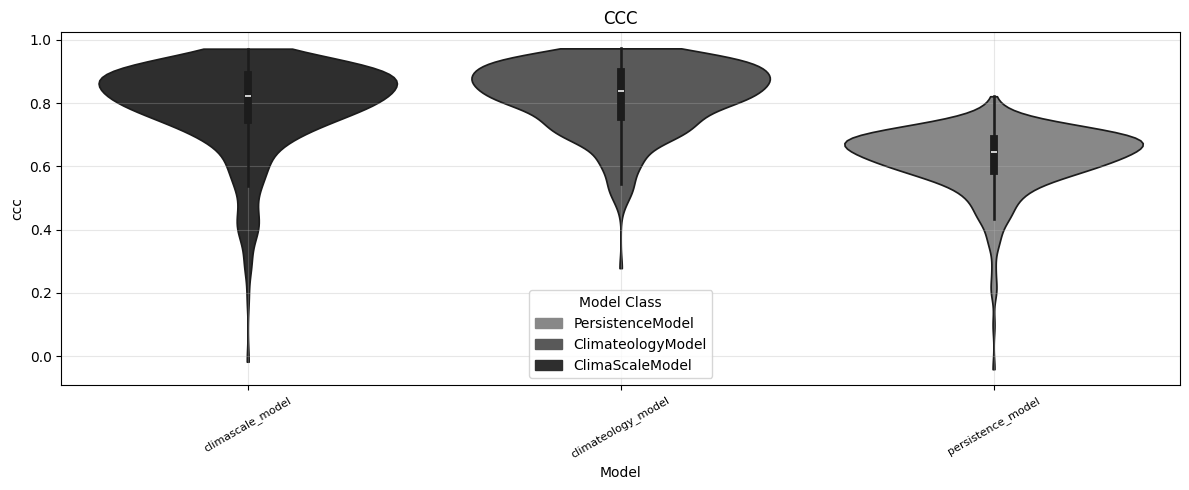

In [7]:
from src.evaluation import Evaluator
e = Evaluator([persistence_predictor, climateology, climascale]).add_evaluation(dataset = 'test')
e.plotter.plot_single_metric('ccc',0, plot_type='violin', log=  False).show()

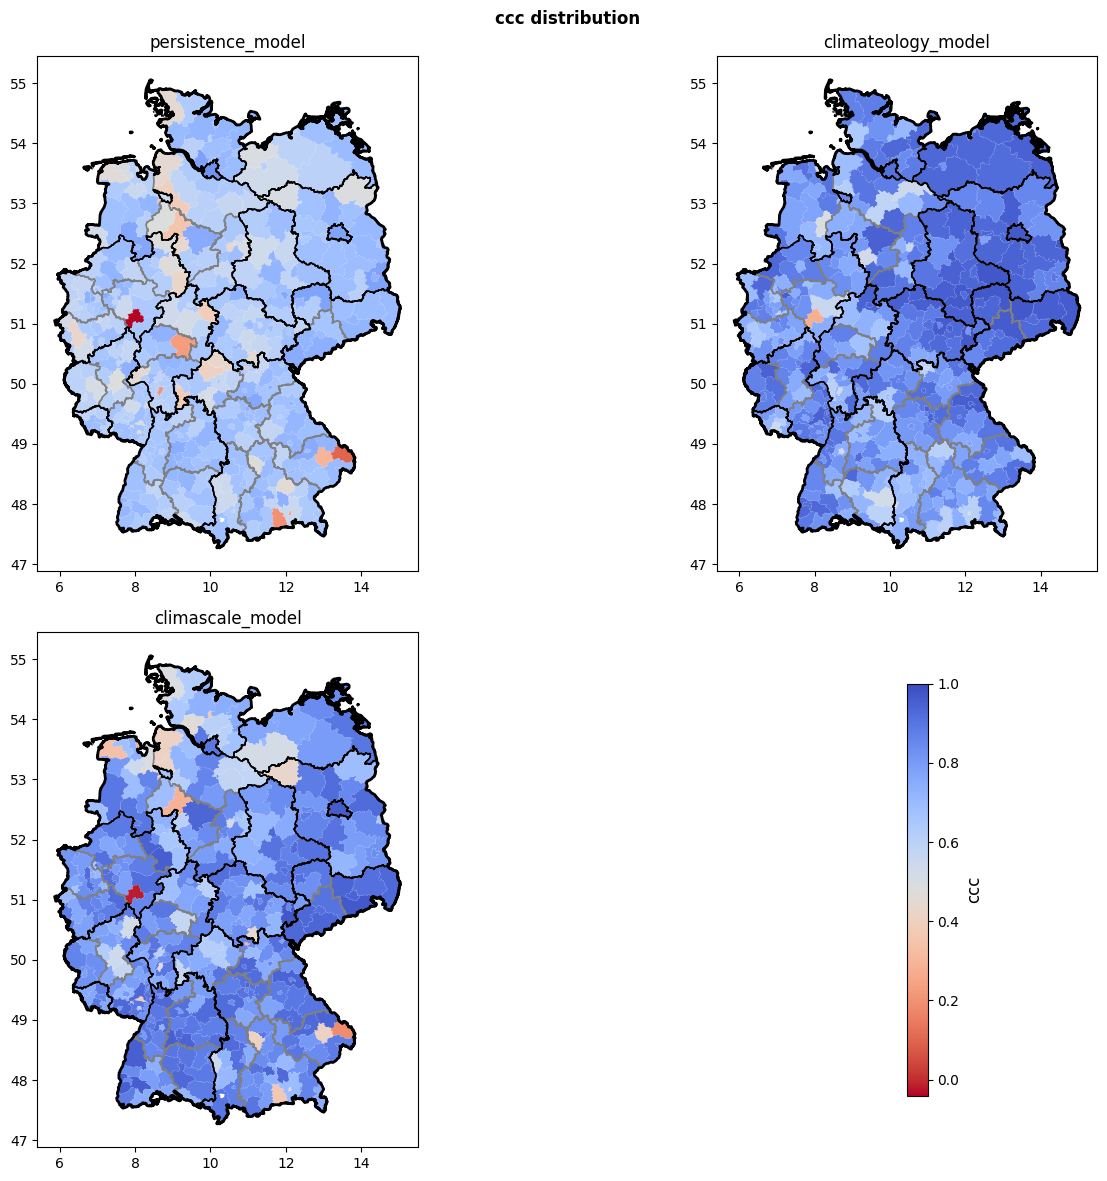

In [8]:
e.plotter.plot_single_metric('ccc',0, plot_type='map', log = False, reverse_scale=True)